# Assignment 4: Regularization 

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?

- *The intuition is that there is a "charge" for the model or a "buying" of larger slope coefficients that boosts error. By penalizing the mean squared error, it is increased in proportion to the amount of coefficient "purchased". The absolute value penalty is LASSO, which forces the model to pick more predictive variables and reduce the size of coefficients, resulting in interpretable and reliable models.*

2. How does regularization provide a way of exploring the bias-variance trade-off?

- *It introduces a tuning parameter that controls model complexity. Increasing the regularization strength (like large alpha values) increases bias but reduces variance, while decreasing it lowers bias but increases variance. By selecting a regularization parameter (like cross-validation), bias and variance can be balanced to have the best performance.*

3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?

- *LASSO sends coefs to zero as alpha increases, removing variables from the model and selecting a model specification for you ("zeros out" variables). Ridge smoothly shrinks all teh coefs towards zero, but never removes a variable completely.Typically, Ridge performs better, while LASSO provides more interpretable results.*
  
4. How do we typically scale variables for use in regularized regression? Why?

- *Variables are scaled using standardization, where you subtract the training mean and divide by the training standard deviation. This is done so that all features are on the same scale before applying regularization. Since methods discusses (like LASSO) penalize the size of coefficients, it is good practice to ensure that the penalty is applied fairly across all variables.*

5. How is the penalty $\alpha$ typically selected?

- *Alpha is selected using cross-validation. A range of possible values is tested, and for each one, the model computes the validation error using k-fold cross-validation. The value of alpha that minimizes the cross-validated error is chosen as the optimal penalty (stored as model.alpha_).*
  
6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

- *No, the penalty term is not included when evaluating cross-validated MSE. While the model is trained using a loss function that includes the penalty, cross-validation evaluates performance using only the prediction error (MSE). This is because we want to measure how well the model predicts unseen data, and the penalty term is only used to control model complexity during training, not to assess predictive accuracy.*

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them. 
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

## Question 2 
1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them. 

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

df = pd.read_csv('./data/cars_hw.csv')
df.head()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


In [5]:
# Calculate the age of each car
df['Age'] = 2026 - df['Make_Year']

In [6]:
X = df[['Mileage_Run', 'Age']]
X.head()

,Mileage_Run,Age
0,44611,9
1,20305,10
2,29540,7
3,35680,9
4,25126,9


In [26]:
# third degree poly expander
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X)
poly_names = poly.get_feature_names_out()

# z-score normalization
scaler = StandardScaler()
X_poly_scaled = scaler.fit_transform(X_poly)

y = df['Price']
alpha_grid = np.logspace(1, 3, 20)
model = LassoCV(cv=10, 
                alphas=alpha_grid,
                random_state=100)
model = model.fit(X_poly, y)

index_star = np.argmin( np.median(model.mse_path_,axis=1) )
alpha_star = model.alphas_[index_star]

/Users/madiheath/Documents/spring26/machine_learning/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.947e+13, tolerance: 1.199e+10
  model = cd_fast.enet_coordinate_descent_gram(
/Users/madiheath/Documents/spring26/machine_learning/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.920e+13, tolerance: 1.199e+10
  model = cd_fast.enet_coordinate_descent_gram(
/Users/madiheath/Documents/spring26/machine_learning/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might w

Optimal cost hyperparameter: 2.620398528858349


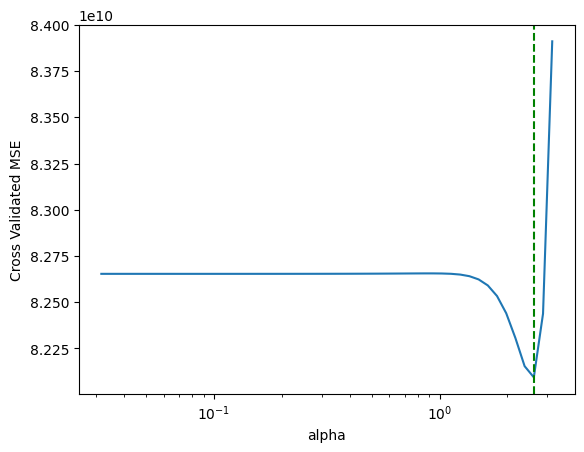

In [25]:
sns.lineplot( x=model.alphas_, y= np.median(model.mse_path_,axis=1) )
plt.axvline(x=alpha_star, color='green', linestyle='--', 
            linewidth=1.5)
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Cross Validated MSE")
print(f'Optimal cost hyperparameter: {alpha_star}')

Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?

In [38]:
model = LinearRegression()
model.fit(X_poly_scaled, df['Price'])

coefs = pd.Series(model.coef_, index=feature_names)
coefs['Mileage_Run Age']

np.float64(-1671212.3563918832)

- The sign of the interaction is negative (as mileage and age increase, price decreases more)

 Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)

In [15]:
from sklearn.linear_model import LassoCV

alphas = np.logspace(1, 3, 20)

lasso_cv = LassoCV(alphas=alphas, cv=20, random_state=100)
lasso_cv.fit(X_poly_scaled, df['Price'])

print("Best alpha:", lasso_cv.alpha_)

lasso_coefs = pd.Series(lasso_cv.coef_, index=X_poly_scaled.columns)
print(lasso_coefs)

Best alpha: 69.51927961775606
Mileage_Run          611783.868767
Age                 -397507.787042
Mileage_Run^2       -519555.261867
Mileage_Run Age     -473871.400459
Age^2                230721.078724
Mileage_Run^3         97835.641353
Mileage_Run^2 Age    318218.774588
Mileage_Run Age^2    -35056.210190
Age^3                 42493.187416
dtype: float64


/Users/madiheath/Documents/spring26/machine_learning/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.385e+10, tolerance: 1.268e+10
  model = cd_fast.enet_coordinate_descent_gram(
/Users/madiheath/Documents/spring26/machine_learning/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.463e+11, tolerance: 1.268e+10
  model = cd_fast.enet_coordinate_descent_gram(
/Users/madiheath/Documents/spring26/machine_learning/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might w

Plot the cross-validated MSE by $\alpha$.

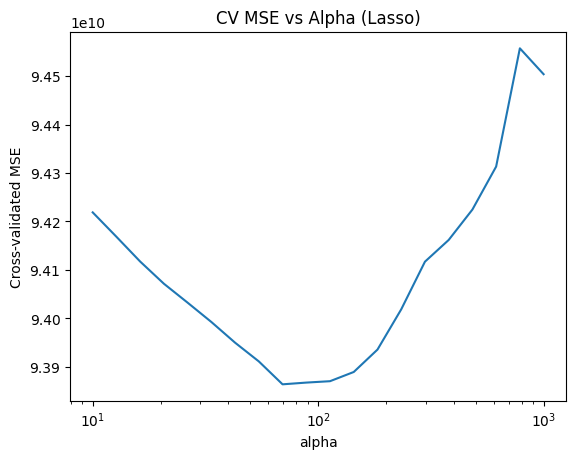

In [ ]:
# Mean MSE across folds for each alpha
mean_mse = np.mean(lasso_cv.mse_path_, axis=1)

plt.figure()
plt.plot(lasso_cv.alphas_, mean_mse)

plt.xscale('log')  
plt.xlabel('alpha')
plt.ylabel('Cross-validated MSE')
plt.title('CV MSE vs Alpha (Lasso)')
plt.show()

Plot the coefficient paths by $\alpha$.

/Users/madiheath/Documents/spring26/machine_learning/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.405e+10, tolerance: 1.316e+10
  model = cd_fast.enet_coordinate_descent(
/Users/madiheath/Documents/spring26/machine_learning/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.677e+10, tolerance: 1.316e+10
  model = cd_fast.enet_coordinate_descent(
/Users/madiheath/Documents/spring26/machine_learning/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to inc

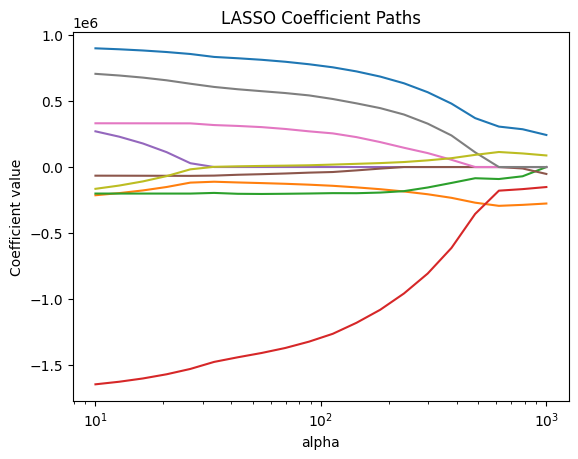

In [33]:
from sklearn.linear_model import Lasso

#loop over alphas and store coefs
coefs = []

for a in alphas:
    model = Lasso(alpha=a, max_iter=10000)
    model.fit(X_poly_scaled, df['Price'])
    coefs.append(model.coef_)

coefs = np.array(coefs)

#plot
plt.figure()

for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i])

plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('Coefficient value')
plt.title('LASSO Coefficient Paths')

plt.show()

Which features are actually selected? What proportion are set equal to zero?

In [35]:
# which features are selected?
feature_names = poly.get_feature_names_out(['Mileage_Run', 'Age'])
lasso_coefs = pd.Series(lasso_cv.coef_, index=feature_names)

selected = lasso_coefs[lasso_coefs != 0]
print(selected)

# which feature are zero?
zero_coefs = lasso_coefs[lasso_coefs == 0]
print(len(zero_coefs))

# proportion of zero
prop_zero = np.mean(lasso_coefs == 0)
print(prop_zero)

Mileage_Run          611783.868767
Age                 -397507.787042
Mileage_Run^2       -519555.261867
Mileage_Run Age     -473871.400459
Age^2                230721.078724
Mileage_Run^3         97835.641353
Mileage_Run^2 Age    318218.774588
Mileage_Run Age^2    -35056.210190
Age^3                 42493.187416
dtype: float64
0
0.0


- All features are selected and none of the coefficients are set to zero. The proportion of coefficients set to zero is 0%. This indicates that the alpha chosen by the cross-validation was not large enough to shrink any coefficients to zero (LASSO does not perform feature selection in this case).

Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [37]:
linear_coefs = pd.Series(model.coef_, index=feature_names)
lasso_coefs = pd.Series(lasso_cv.coef_, index=feature_names)

comparison = pd.DataFrame({
    'Linear': linear_coefs,
    'LASSO': lasso_coefs
})

comparison

,Linear,LASSO
Mileage_Run,242953.216388,611783.868767
Age,-276500.895776,-397507.787042
Mileage_Run^2,-0.000000,-519555.261867
Mileage_Run Age,-151598.545767,-473871.400459
Age^2,-0.000000,230721.078724
Mileage_Run^3,-52410.347536,97835.641353
Mileage_Run^2 Age,-0.000000,318218.774588
Mileage_Run Age^2,-0.000000,-35056.210190
Age^3,87796.740706,42493.187416


Yes, several coefficients increase in magnitude from linear regression to LASSO. For example, Mileage_Run, Age, and the interaction term Mileage_Run Age all have larger absolute values under LASSO than in the linear regression model; however, no coefficients change sign; all variables retain the same positive/negative direction across both models. 

## Question 3

Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.

In [ ]:
df = pd.read_csv("./data/heart)